# Exercise session 11: Features, Kernels, and Neural Networks

## Exercise 1: Feature Engineering

1. Open the TensorFlow playground at https://playground.tensorflow.org/, select the dataset with
two clusters, the features $x_1$ and $x_2$ and keep zero hidden layers and linear activation. Train the model
by clicking on the play button. Does the classifier correctly learn the boundary?
2. Now select the XOR dataset and repeat the training? Does the classifier work?
3. Keeping the same dataset, try adding and removing features to see if the performance improves.
What is the minimal number of features that are needed to correctly learn the boundary? What are
the features? Why do they work well?
4. Now pick the concentric circles dataset. Repeat the feature selection process from the last point and
answer the same questions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn import metrics
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_moons
from sklearn.datasets import make_circles


## Exercise 2: Kernel Ridge Regression

1. Generate an artificial dataset with random input points $X$ uniformly-distributed in the range $[−4, +4]$
and ground-truth function $f^*(X) = \sin(X) + 2 \cos(4X) + 1
2 \sin(X + 1)$. We are going to try to learn
this dataset from the observations $y(X) = f^∗(X) + \eta$, with $\eta \sim N(0, 1)$. Plot $n = 50$ training points
with their labels.

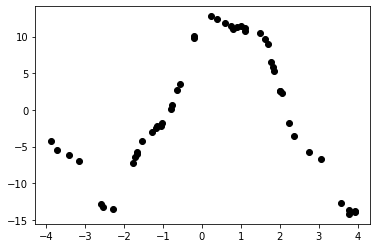

In [2]:
# Generate train and test set

n = 50

X_train = np.random.rand(n, 1) * 8 - 4


def ground_truth(x):
    y = np.sin(x) + 2 * np.cos(4 * x) + 12 * np.sin(x + 1)  # Combination of sinusioids
    return y.squeeze()


y_train = ground_truth(X_train) + np.random.rand(n)

X_test = np.linspace(-4, 4, 100).reshape(-1, 1)

y_test = ground_truth(X_test)

plt.scatter(X_train, y_train, color='k')


2. Try to learn this function using `sklearn.kernel_ridge.KernelRidge` with a linear "kernel", and regularization strength $\alpha = 0.01$. Plot the predictor on the test set and compare with the ground-truth.
Comment.

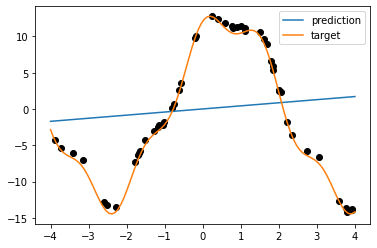

In [3]:
# "Kernel" ridge regression with the linear kernel

krr = KernelRidge(alpha=0.01, kernel='linear')
krr.fit(X_train, y_train)
y_test_pred = krr.predict(X_test)

# Plot the training set, the predictor, and the ground trouth

plt.scatter(X_train, y_train, color='k')
plt.plot(X_test, y_test_pred, label='prediction')
plt.plot(X_test, y_test, label='target')
plt.legend()


3. Repeat substituting the linear kernel first with the RBF kernel and then with the Laplacian kernel. How
do the functions learned by these kernels differ? Can you imagine why?

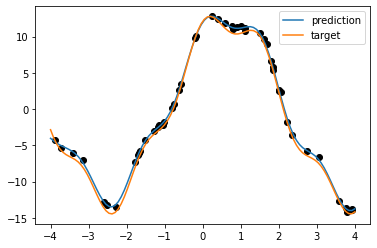

In [4]:
# Kernel ridge regression with the RBF kernel

krr = KernelRidge(alpha=0.01, kernel='rbf')
krr.fit(X_train, y_train)
y_test_pred = krr.predict(X_test)

# Plot the training set, the predictor, and the ground trouth

plt.scatter(X_train, y_train, color='k')
plt.plot(X_test, y_test_pred, label='prediction')
plt.plot(X_test, y_test, label='target')
plt.legend()


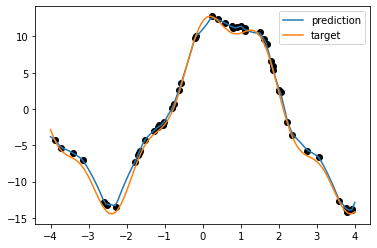

In [5]:
# Kernel ridge regression with the Laplacian kernel exp(-||x-y||)

krr = KernelRidge(alpha=0.01, kernel='laplacian')
krr.fit(X_train, y_train)
y_test_pred = krr.predict(X_test)

# Plot the training set, the predictor, and the ground trouth

plt.scatter(X_train, y_train, color='k')
plt.plot(X_test, y_test_pred, label='prediction')
plt.plot(X_test, y_test, label='target')
plt.legend()


## Exercise 3: Kernelized Logistic Regression

What about classification? Previously, in the class, we have seen that a linear model for classification is logistic regression, which solves the following optimization problem $$\min_w \sum_{i=1}^n \log (1 + \exp (-y_i(X_i \cdot w))).$$ Can we use it with kernels to classify non-linearly-separable data? The answer is yes, by mapping the data in the feature space, i.e. $X_i \to \phi(X_i)$, and applying the representer theorem, i.e. $w = \sum_{j=1}^n \alpha_j \phi(X_j)$, we obtain
$$\min_\alpha \sum_{i=1}^n \log \left(1 + \exp \left(-y_i \left(\phi(X_i)\sum_{j=1}^n \alpha_j \phi(X_j)\right)\right)\right),$$
$$\min_\alpha \sum_{i=1}^n \log \left(1 + \exp \left(-y_i \left(\sum_{j=1}^n \alpha_j K(X_i, X_j)\right)\right)\right).$$
Therefore, it is sufficient to substitute the data matrix $X$ with the kernel matrix $K_{ij} = K(X_i, X_j)$ in the sklearn algorithm!

1. Using `sklearn.linear_model.LogisticRegression`, fit the two-moons dataset with the RBF kernel and predict the value of the model on the test points. You can use `sklearn.metris.pairwise` to compute the kernel. Set the regularization strength $\gamma=10$. Use the code in the notebook to plot the training points and the decision boundary.


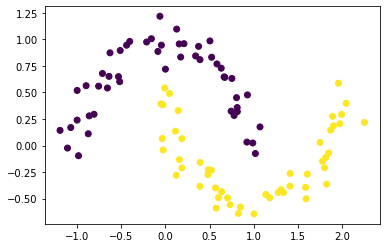

In [6]:
X_train, y_train = make_moons(n_samples=100, noise=0.1)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)


In [7]:
# Returns a vector of test points and the coordinate of the meshgrid
# Pass X_test to the kernel and use x_mesh to plot the decision boundary

def test_meshgrid(X_train):

    x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
    y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
    x_mesh, y_mesh = np.meshgrid(
        np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

    X_test = np.c_[x_mesh.ravel(), y_mesh.ravel()]

    return X_test, x_mesh, y_mesh


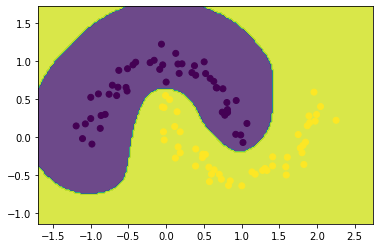

In [8]:
# Kernelized Logistic regression with the RBF kernel

gamma = 10
K_trtr = metrics.pairwise.rbf_kernel(X_train, X_train, gamma=gamma)
klr = LogisticRegression()
klr.fit(K_trtr, y_train)

X_test, x_mesh, y_mesh = test_meshgrid(X_train)

K_tetr = metrics.pairwise.rbf_kernel(X_test, X_train, gamma=gamma)
y_pred = klr.predict(K_tetr)
y_pred = y_pred.reshape(x_mesh.shape)
plt.contourf(x_mesh, y_mesh, y_pred, alpha=0.8)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)


2. Repeat with the Laplacian kernel. How do the decision boundaries learned with the two kernels differ? Why?

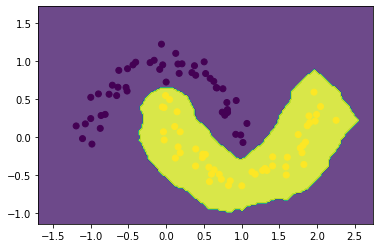

In [9]:
# Kernelized Logistic regression with the Laplacian kernel

gamma = 10
K_trtr = metrics.pairwise.laplacian_kernel(X_train, X_train, gamma=gamma)
klr = LogisticRegression()
klr.fit(K_trtr, y_train)

X_test, x_mesh, y_mesh = test_meshgrid(X_train,)

K_tetr = metrics.pairwise.laplacian_kernel(X_test, X_train, gamma=gamma)
y_pred = klr.predict(K_tetr)
y_pred = y_pred.reshape(x_mesh.shape)
plt.contourf(x_mesh, y_mesh, y_pred, alpha=0.8)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)


## Exercise 4: Artificial Neural Networks with Simple Datasets

1. Open the TensorFlow playground at https://playground.tensorflow.org/ again, select the spiral dataset, and train the model as done for the previous datasets. Is there any feature
combination that can be used to correctly learn the boundary?
2. Now consider the $x_1$ and $x_2$ features, play with the neural network architecture by progressively
adding hidden layers and hidden units, try different activation functions and tune the neural network
hyperparameters, i.e. the learning rate, the batch size, etc. Is the neural network able to learn the spiral?
If yes, what is a suitable combination of network’s architecture, hyperparameters and activation
function that does the job?
3. Repeat for the XOR and the concentric circles datasets.
